# Практична робота №1
## Задачі регресії в машинному навчанні

**Варіант 1**

**Мета:** закріпити знання про алгоритми регресії в машинному навчанні шляхом вирішення прикладної задачі.

Робота виконана за структурою з методичних вказівок: аналіз даних → кореляція → навчання лінійної регресії → прогноз → оцінювання похибки → коефіцієнти моделі.

### 1. Імпорт бібліотек

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline

### 2. Завантаження даних

In [8]:
DATA_FILE = "Лабораторна_робота_1_Варіант_1_дані.csv"

df = pd.read_csv(DATA_FILE)
df.head()

,Density,M4,AgeAvg,Speed
0,0.5,0.1,7.5,42.6
1,0.6,0.1,7.5,45.0
2,0.6,0.1,7.5,49.5
3,0.6,0.1,7.5,58.9
4,0.9,0.1,7.5,48.7


Я завантажила набір даних відповідно до свого варіанта. Набір містить 300 спостережень та 4 змінні: Density, M4, AgeAvg і Speed. Ці дані будуть використані для подальшого проведення регресійного аналізу.

### 3. Первинний аналіз даних

In [9]:
df.info()

print("Описова статистика:")
display(df.describe())

print("Кількість пропущених значень:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  300 non-null    float64
 1   M4       300 non-null    float64
 2   AgeAvg   300 non-null    float64
 3   Speed    300 non-null    float64
dtypes: float64(4)
memory usage: 9.5 KB
Описова статистика:


,Density,M4,AgeAvg,Speed
count,300.000000,300.000000,300.000000,300.000000
mean,3.520667,0.077000,11.040000,29.271667
std,1.598590,0.024962,3.116211,11.706121
min,0.500000,0.050000,7.500000,11.000000
25%,2.375000,0.050000,7.500000,20.150000
50%,3.600000,0.100000,11.500000,26.800000
75%,4.700000,0.100000,15.000000,35.650000
max,6.900000,0.100000,15.000000,61.600000


Кількість пропущених значень:
Density    0
M4         0
AgeAvg     0
Speed      0
dtype: int64


За допомогою head(), info() та describe() я переглянула структуру та основні характеристики набору даних. У таблиці міститься 300 спостережень, усі змінні мають числовий тип даних. Пропущені значення у наборі даних відсутні.

Описова статистика дає змогу оцінити середні, мінімальні та максимальні значення змінних, а також їхній розкид.

### 4. Графічний аналіз залежностей

In [ ]:
df.plot.scatter('Density', 'Speed')


In [ ]:
df.plot.scatter('M4', 'Speed')


In [ ]:
df.plot.scatter('AgeAvg', 'Speed')


Для попереднього дослідження характеру залежностей я побудувала точкові графіки між залежною змінною Speed та кожною з незалежних змінних: Density, M4 і AgeAvg.

За графіками можна візуально оцінити характер залежності між змінними та перевірити, чи має вона приблизно лінійний вигляд.

На графіку Speed від Density спостерігається виражена спадна тенденція: зі збільшенням Density значення Speed загалом зменшується.

### 5. Кореляційна матриця

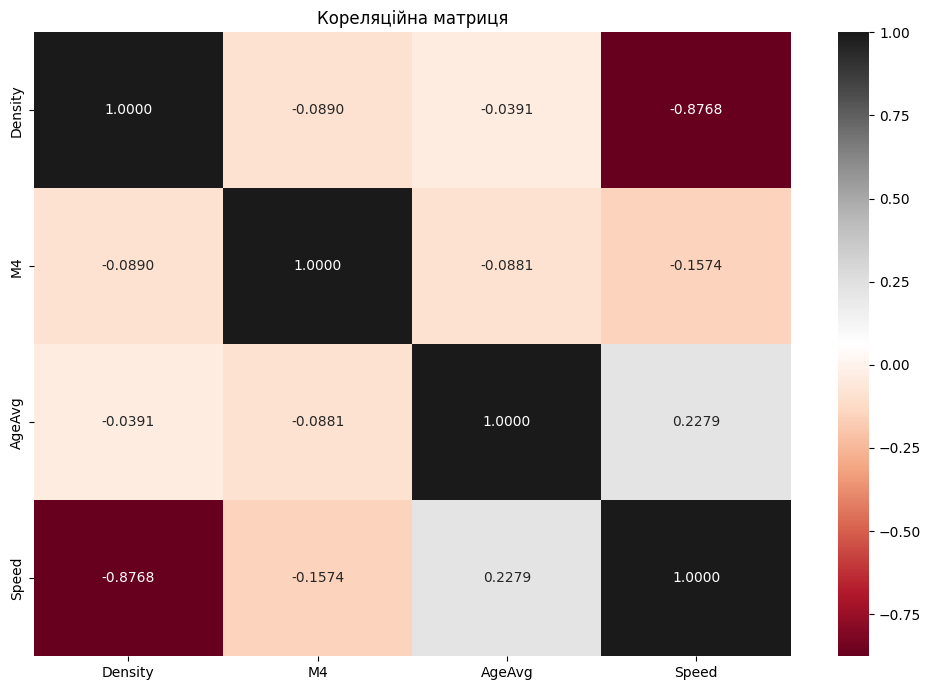

In [21]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".4f", cmap="RdGy")
plt.title("Кореляційна матриця")
plt.tight_layout()

За допомогою кореляційної матриці я визначила напрямок і силу лінійного зв’язку між змінними.

Для залежної змінної Speed найбільш виражений зв’язок спостерігається зі змінною Density. Коефіцієнт кореляції між ними становить приблизно -0.877, що відповідає сильному негативному лінійному зв’язку.

Між M4 і Speed спостерігається слабкий негативний зв’язок, а між AgeAvg і Speed — слабкий позитивний зв’язок.

Отже, серед розглянутих змінних найбільш помітний лінійний зв’язок із Speed має Density.

### 6. Визначення предикторів і залежної змінної

Залежна змінна — **Speed**. Незалежні змінні — **Density, M4, AgeAvg**.

In [24]:
X = df[["Density", "M4", "AgeAvg"]]
y = df["Speed"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300, 3)
y shape: (300,)


У своїй роботі я визначила Speed як залежну змінну, значення якої необхідно прогнозувати.

Незалежними змінними, або предикторами, є Density, M4 та AgeAvg. Саме ці змінні використовуються моделлю для прогнозування значення Speed.

Таким чином:

X — незалежні змінні Density, M4, AgeAvg;  
y — залежна змінна Speed.

### 7. Поділ на навчальну і тестову вибірки

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

print("Навчальна вибірка:", len(X_train))
print("Тестова вибірка:", len(X_test))

Навчальна вибірка: 180
Тестова вибірка: 120


Я поділила набір даних на навчальну та тестову вибірки у співвідношенні 60% до 40%, як у прикладі методички.

Навчальна вибірка використовується для навчання моделі лінійної регресії, а тестова — для перевірки точності прогнозування на даних, які не використовувалися під час навчання.

У результаті 180 спостережень було використано для навчання моделі, а 120 — для її тестування.

### 8. Навчання лінійної регресійної моделі

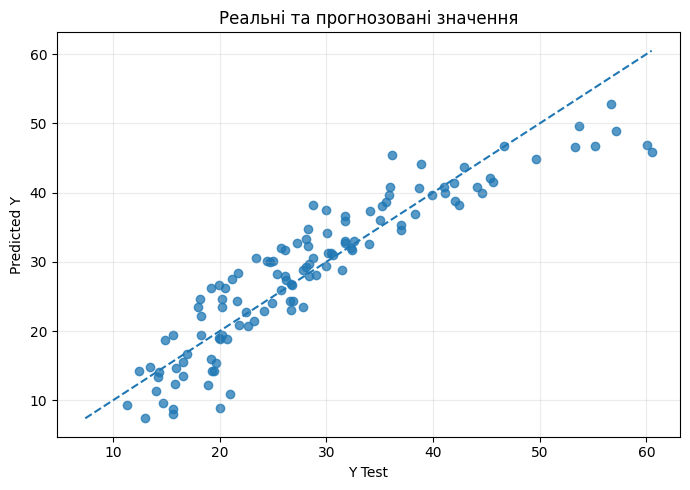

In [ ]:
lm = LinearRegression()
lm.fit(X_train, y_train)

predictions = lm.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions, alpha=0.75)
mn = min(y_test.min(), predictions.min())
mx = max(y_test.max(), predictions.max())
plt.plot([mn, mx], [mn, mx], "--")
plt.xlabel("Y Test")
plt.ylabel("Predicted Y")
plt.title("Реальні та прогнозовані значення")
plt.grid(alpha=0.25)
plt.tight_layout()

Для вирішення задачі я використала модель лінійної регресії LinearRegression.

Спочатку модель була навчена на навчальній вибірці за допомогою предикторів Density, M4 та AgeAvg. Після навчання я отримала прогнозовані значення Speed для тестової вибірки.

На графіку показано співвідношення фактичних (Y Test) та прогнозованих (Predicted Y) значень. Чим ближче прогнозовані значення до фактичних, тим менша похибка прогнозу.

### 9. Оцінювання якості моделі

In [ ]:
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 3.5075
MSE: 20.4610
RMSE: 4.5234
R²: 0.8355


Для оцінювання якості побудованої моделі я використала три показники: MAE, MSE та RMSE.

Отримані результати:

MAE = 3.5075
MSE = 20.4610
RMSE = 4.5234

MAE показує середню абсолютну величину помилки прогнозу. MSE визначає середню квадратичну помилку, тому більші помилки мають більший вплив на цей показник. RMSE є квадратним коренем із MSE та має ті самі одиниці вимірювання, що й залежна змінна Speed.

Отримані значення показують величину похибок моделі на тестовій вибірці.

### 10. Розподіл похибок

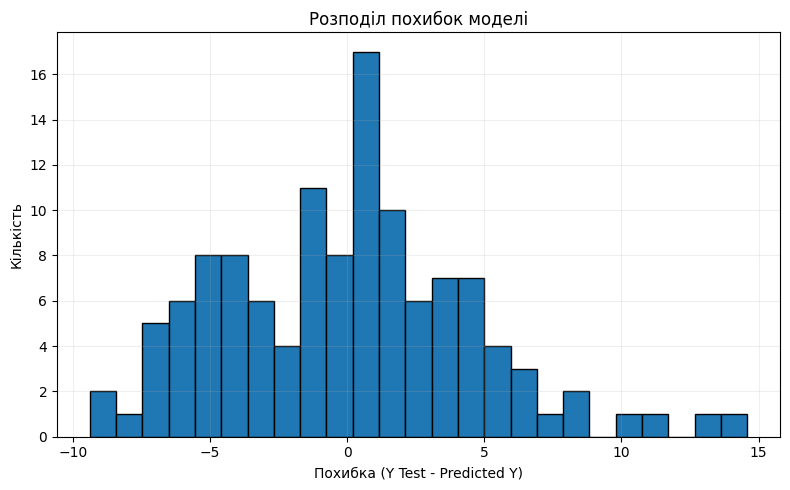

In [ ]:
residuals = y_test - predictions

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25, edgecolor="black")
plt.xlabel("Похибка (Y Test - Predicted Y)")
plt.ylabel("Кількість")
plt.title("Розподіл похибок моделі")
plt.grid(alpha=0.2)
plt.tight_layout()

Я визначила похибки моделі як різницю між фактичними та прогнозованими значеннями:

Y Test − Predicted Y.

Побудована гістограма показує розподіл цих похибок. За допомогою цього графіка можна оцінити, наскільки похибки зосереджені навколо нульового значення та наскільки рівномірно вони розподілені.

Чим ближче похибки до нульового значення, тим ближчими є прогнозовані значення до фактичних.

### 11. Коефіцієнти регресії

In [ ]:
coefficients = pd.DataFrame({
    "parameter": X.columns,
    "coefficient": lm.coef_
})
coefficients = pd.concat([
    pd.DataFrame({"parameter":["Intercept"], "coefficient":[lm.intercept_]}),
    coefficients
], ignore_index=True)

display(coefficients)

print("Рівняння моделі:")
print(
    f"Speed = {lm.intercept_:.4f} "
    f"{lm.coef_[0]:+.4f}*Density "
    f"{lm.coef_[1]:+.4f}*M4 "
    f"{lm.coef_[2]:+.4f}*AgeAvg"
)

,parameter,coefficient
0,Intercept,52.385023
1,Density,-6.651058
2,M4,-96.670181
3,AgeAvg,0.701135


Рівняння моделі:
Speed = 52.3850 -6.6511*Density -96.6702*M4 +0.7011*AgeAvg


Після навчання моделі я визначила коефіцієнти лінійної регресії для кожного предиктора.

Отримані коефіцієнти показують напрямок і величину зміни прогнозованого значення Speed залежно від відповідного предиктора за незмінності інших змінних.

Отримане рівняння моделі має вигляд:

Speed = 52.3850 − 6.6511·Density − 96.6702·M4 + 0.7011·AgeAvg

Знак коефіцієнта показує напрямок залежності: від’ємний коефіцієнт відповідає зменшенню прогнозованого Speed зі збільшенням відповідної змінної, а додатний — збільшенню.

### 12. Висновок

У ході практичної роботи я провела регресійний аналіз набору даних за допомогою моделі лінійної регресії.

Як залежну змінну я обрала Speed, а як предиктори — Density, M4 та AgeAvg. Я провела первинний аналіз даних, побудувала графіки залежностей, визначила кореляції між змінними, поділила дані на навчальну та тестову вибірки, навчила модель лінійної регресії та оцінила її похибку.

За результатами кореляційного аналізу найбільш виражений лінійний зв’язок із Speed має Density — коефіцієнт кореляції становить приблизно -0.877.

Для тестової вибірки отримано MAE = 3.5075, MSE = 20.4610 та RMSE = 4.5234. Також було побудовано графік фактичних і прогнозованих значень, досліджено розподіл похибок та визначено коефіцієнти регресійної моделі.

У результаті я застосувала основні етапи регресійного аналізу для прогнозування значення Speed за заданими незалежними змінними.